### Baixar dataset

In [214]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster import hierarchy

In [196]:
api = KaggleApi()
api.authenticate()
file = api.dataset_download_files("rohan0301/unsupervised-learning-on-country-data", path='./', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data


In [197]:
original_df = pd.read_csv("Country-data.csv")
df_dd = pd.read_csv("data-dictionary.csv")
original_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Exploração Dados

In [198]:
original_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [199]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


#### 2. Quantos países existem no dataset?
R: 167 países

In [200]:
df = original_df.drop(columns=['country'])

### 3. Visualização dos dados
R: Os gráficos abaixo mostram como os dados estão dispersos e como algumas features possuem outliers. É necessário fazer uma padronização para deixar todos na mesma faixa.

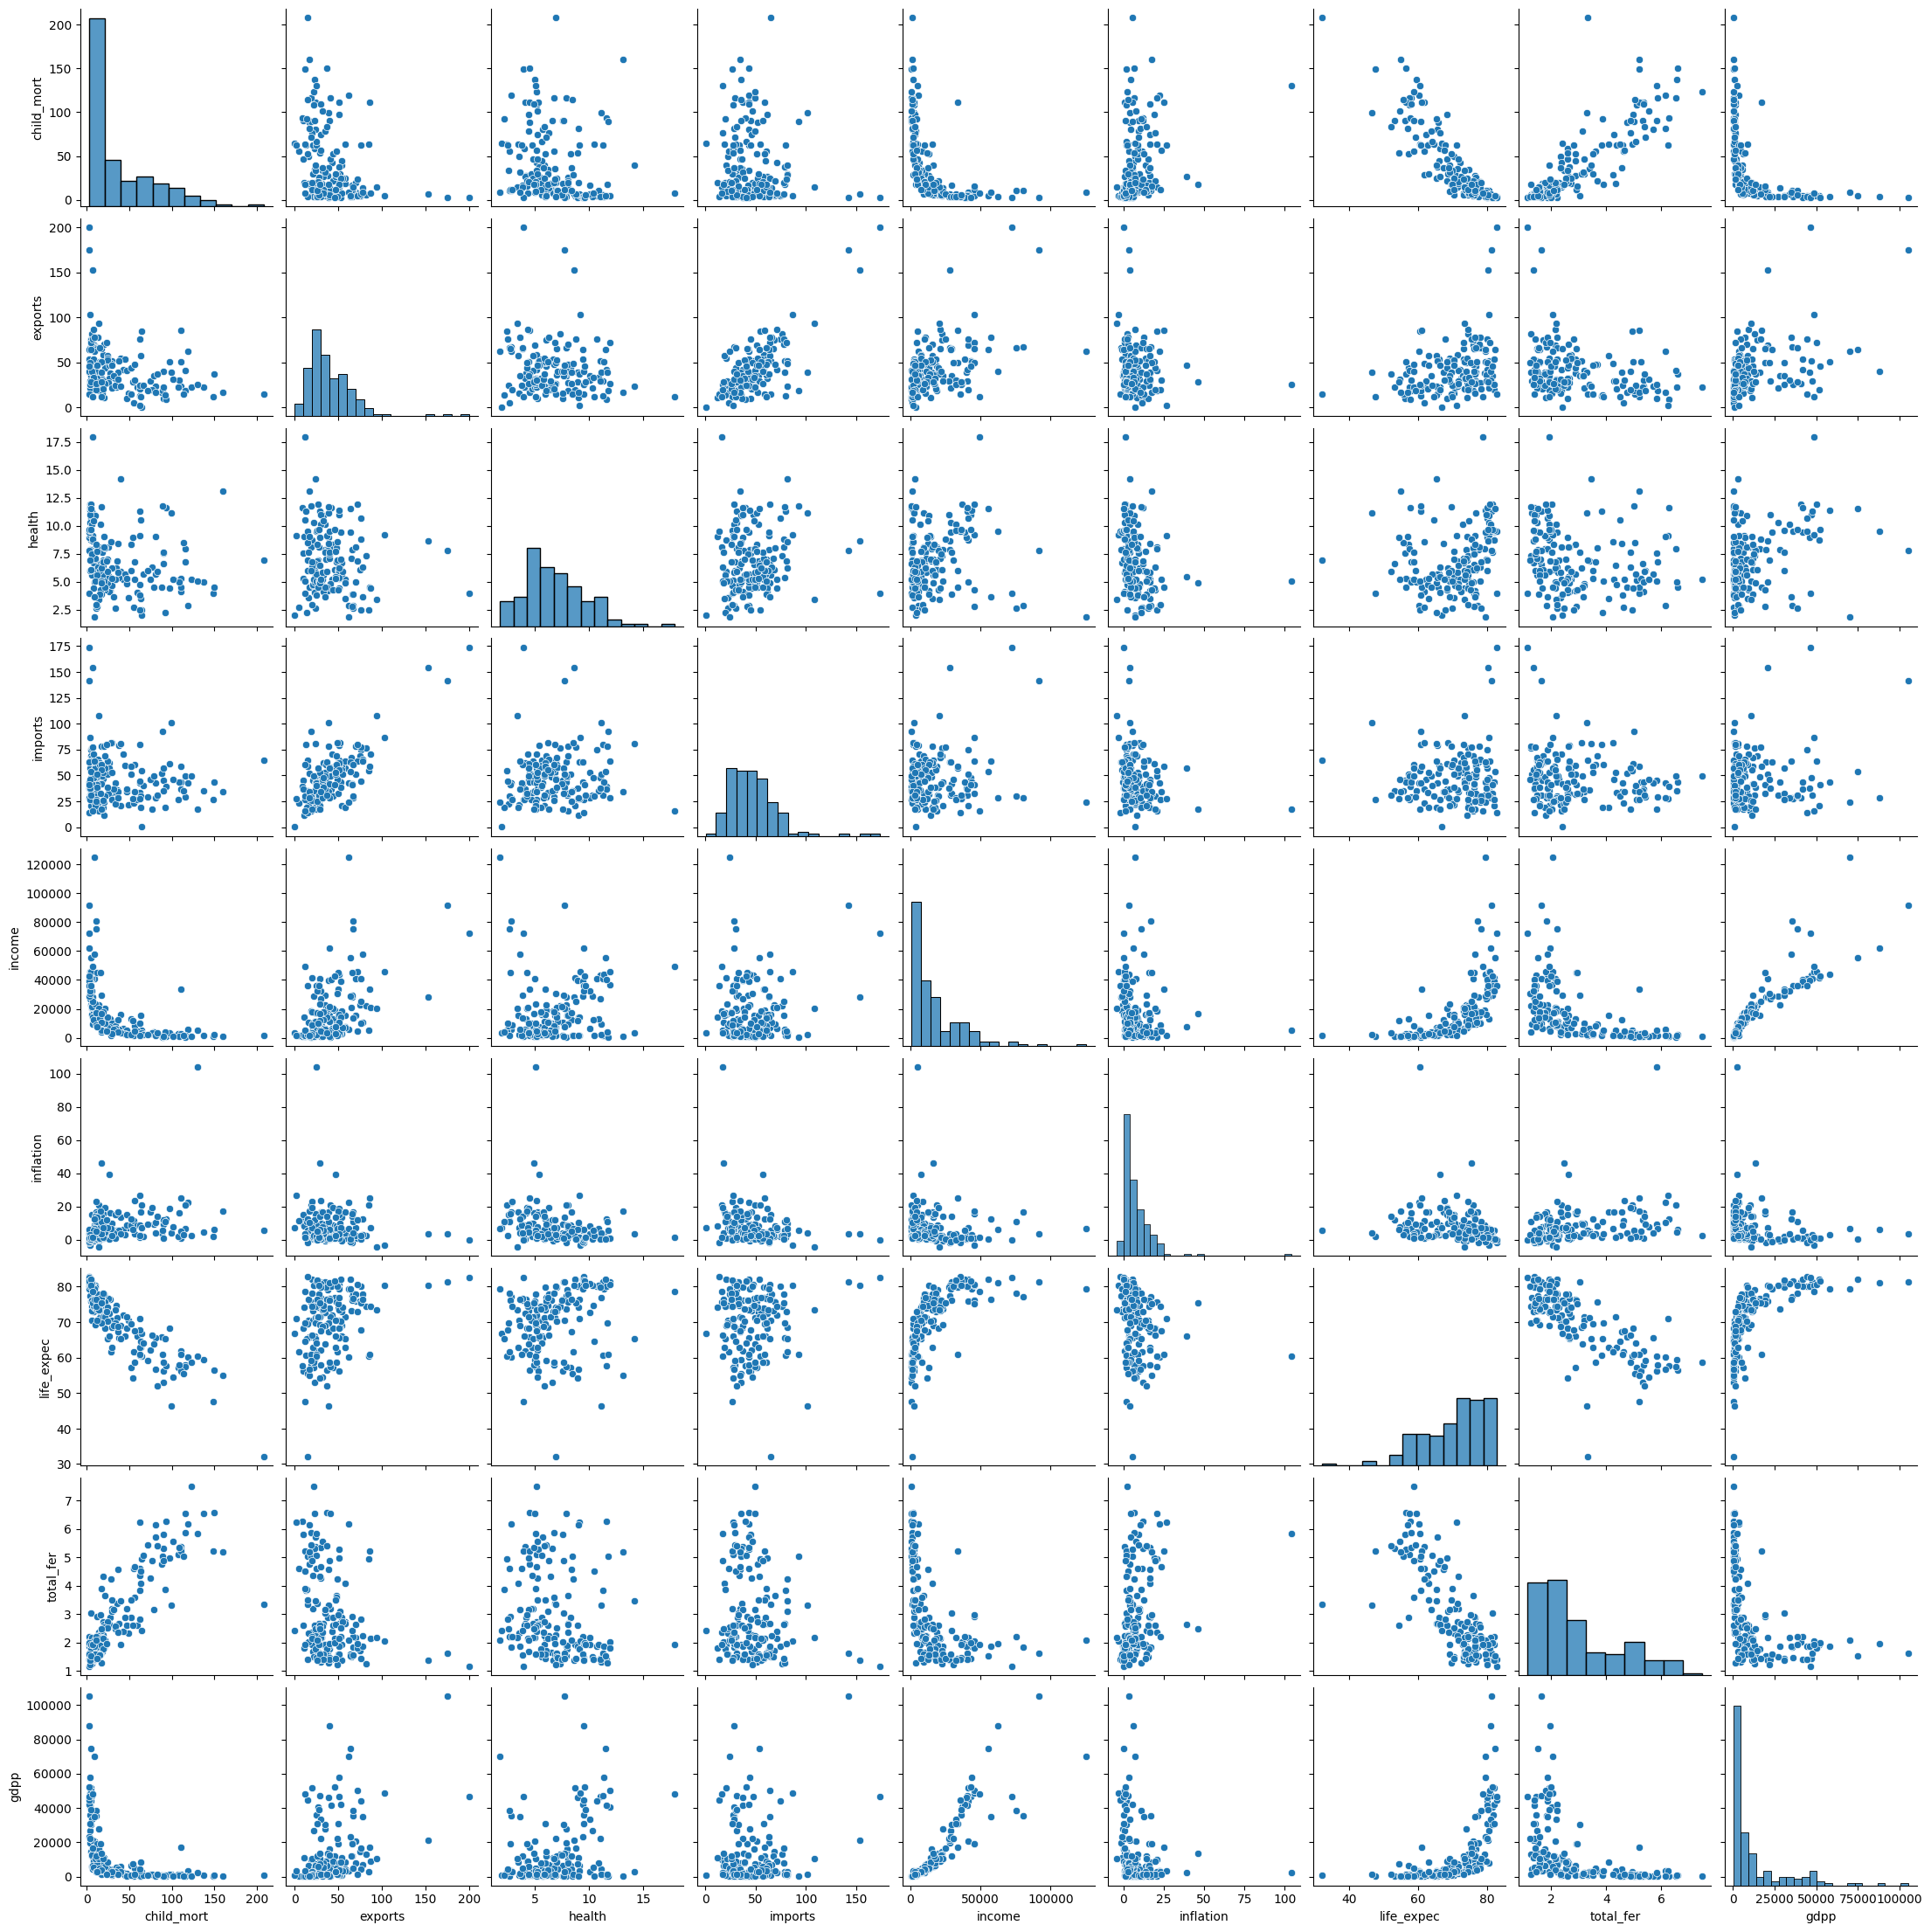

In [201]:
sns.pairplot(df)

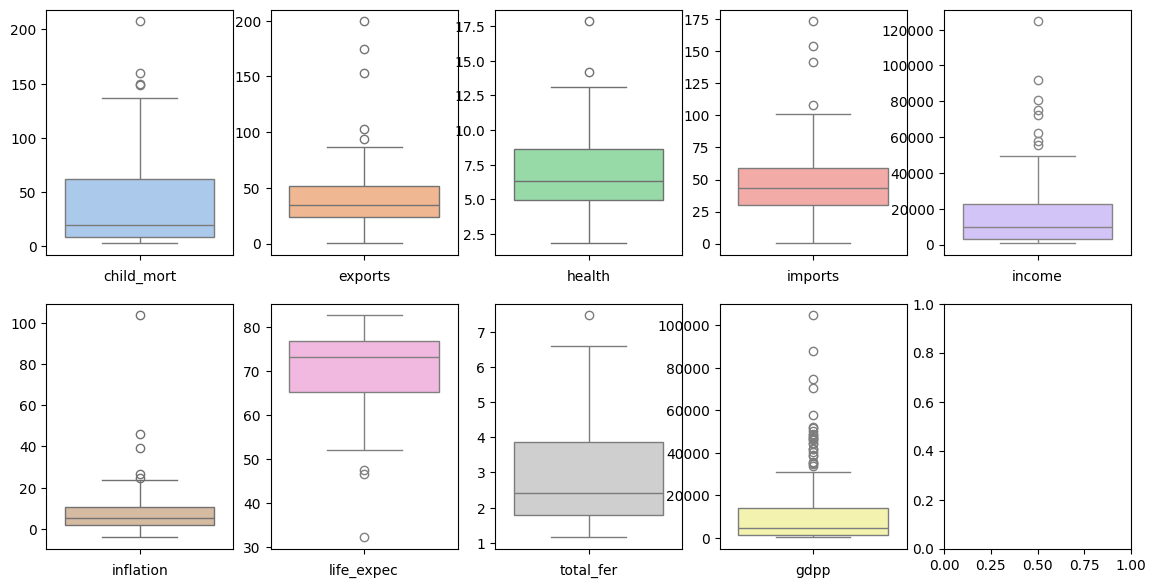

In [202]:
fig, ax = plt.subplots(2, 5, figsize=(14, 7))
colors = sns.color_palette('pastel')

for i, column in enumerate(df.columns):
    sns.boxplot(data=df[column], ax=ax.flatten()[i], color=colors[i])
    ax.flatten()[i].set_ylabel("") 
    ax.flatten()[i].set_xlabel(column) 

plt.show()

array([[<Axes: title={'center': 'child_mort'}>,
        <Axes: title={'center': 'exports'}>,
        <Axes: title={'center': 'health'}>],
       [<Axes: title={'center': 'imports'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'inflation'}>],
       [<Axes: title={'center': 'life_expec'}>,
        <Axes: title={'center': 'total_fer'}>,
        <Axes: title={'center': 'gdpp'}>]], dtype=object)

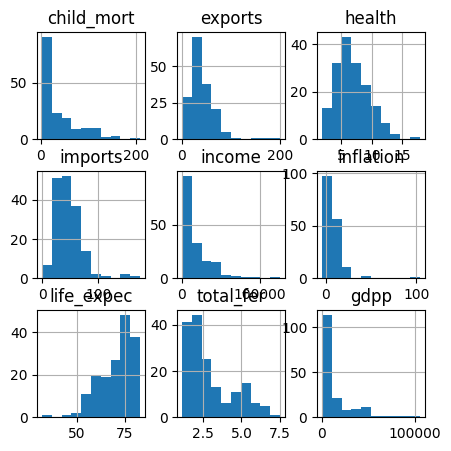

In [203]:
df.hist(figsize=(5,5))

In [204]:
scaler = StandardScaler()
X = scaler.fit_transform(df)


In [205]:
CLUSTERS = 3
SEED = 10

kmeans = KMeans(n_clusters=CLUSTERS, random_state=SEED).fit(X)
df['cluster'] = kmeans.labels_

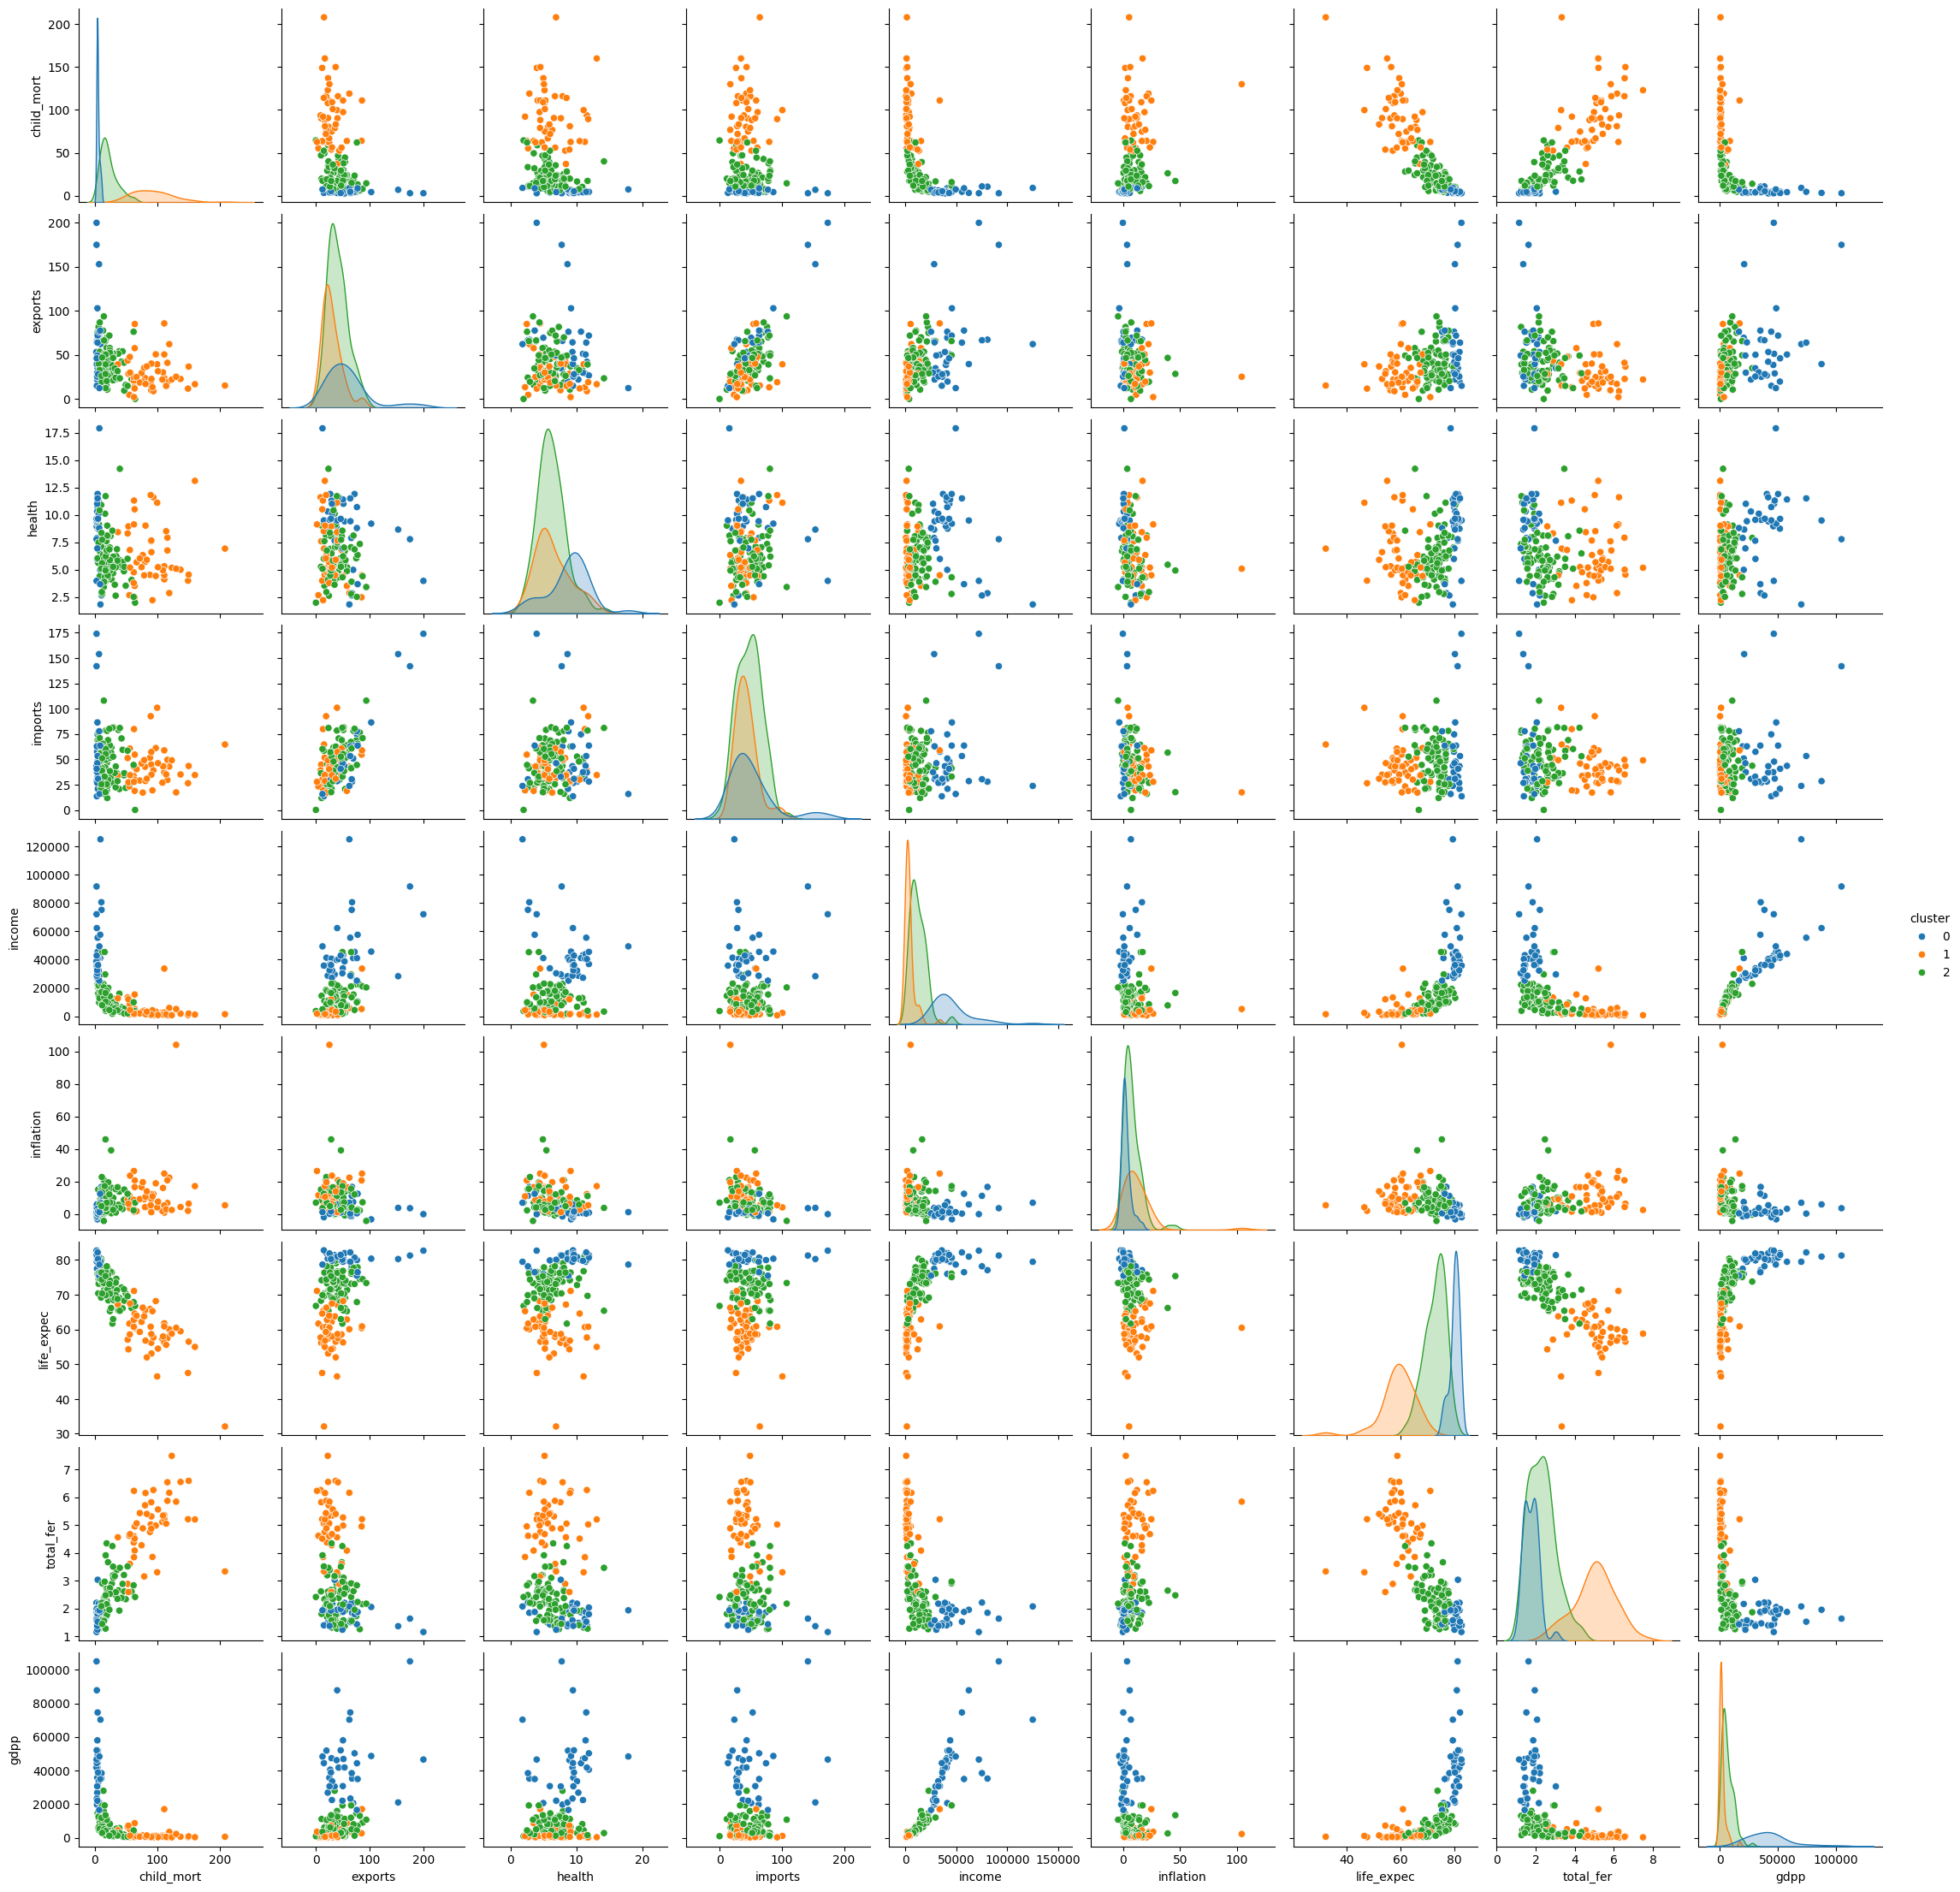

In [206]:
sns.pairplot(df, hue='cluster', palette='tab10')

In [245]:
single_linkage = hierarchy.linkage(X, method='complete', metric='euclidean')

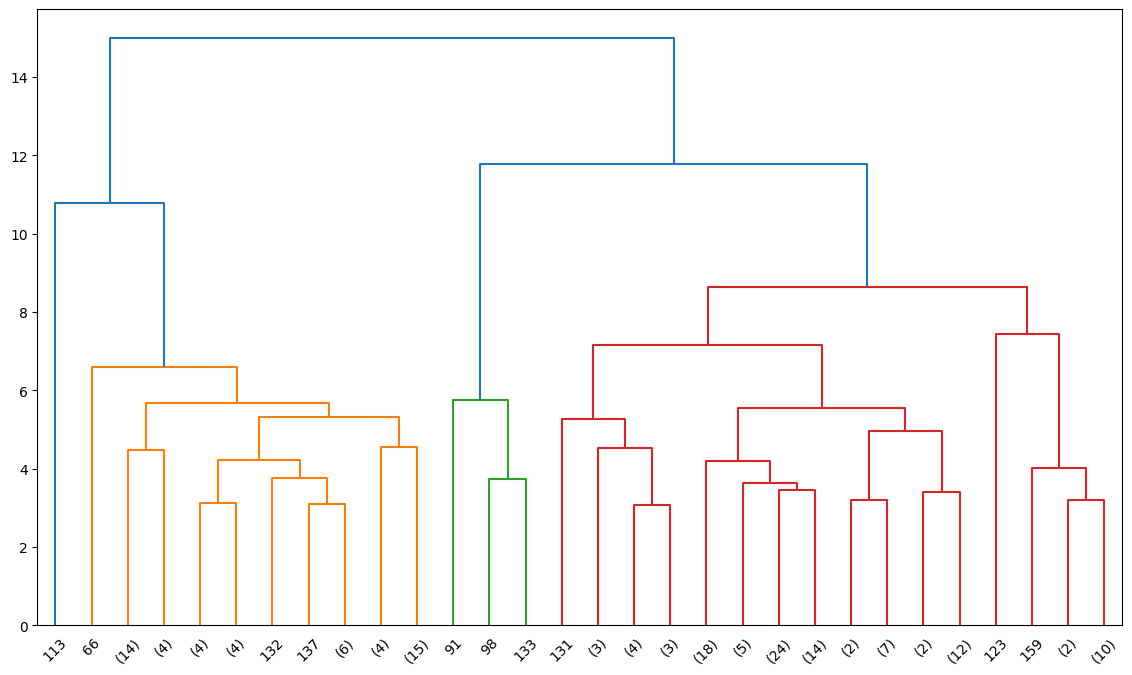

In [246]:
fig, ax = plt.subplots(figsize=(14, 8))
hierarchy.dendrogram(single_linkage, distance_sort=True, show_leaf_counts=True, truncate_mode='lastp')
plt.show()